# Dokumentace figures

Five publication-grade figures for the SUR submission PDF. Run top-to-bottom; everything lands in `docs/figures/` as both PDF (vector) and 300-DPI PNG.

| File | Section | Story |
|---|---|---|
| `fig1_covariance_ablation` | §3.2 | Tied covariance is the audio breakthrough |
| `alt_a_image_robustness`   | §4   | E033 photometrically bulletproof |
| `fig6_det_curve`           | §5   | DET curves with the trimodal-fusion star |
| `alt_c_complementarity`    | §5   | Audio and image fail on disjoint samples |
| `alt_b_progression`        | §7   | 53 experiments, three orders of magnitude |

Self-contained: hardcoded ablation numbers + OOF scores from `cache/oof_scores.pkl`.

In [1]:
from __future__ import annotations
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

P = dict(
    audio="#3A7EC5", audio_lt="#AECDE8",
    image="#C84B2F", image_lt="#EDB49E",
    fusion="#1F9E72", fusion_lt="#8FD9BB",
    mfcc="#7C54B0", mfcc_lt="#C4AFDC",
    amber="#E8A820", ink="#1A2035", sub="#5A6B85",
    grid="#EDF1F8", bg="#FFFFFF",
)
plt.rcParams.update({
    "figure.facecolor": P["bg"], "axes.facecolor": P["bg"],
    "axes.edgecolor": P["sub"], "axes.labelcolor": P["ink"],
    "axes.titlecolor": P["ink"],
    "xtick.color": P["sub"], "ytick.color": P["sub"],
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=300)
    print("saved", name)


## Fig 1 — GMM covariance ablation (E037, §3.2)

saved fig1_covariance_ablation


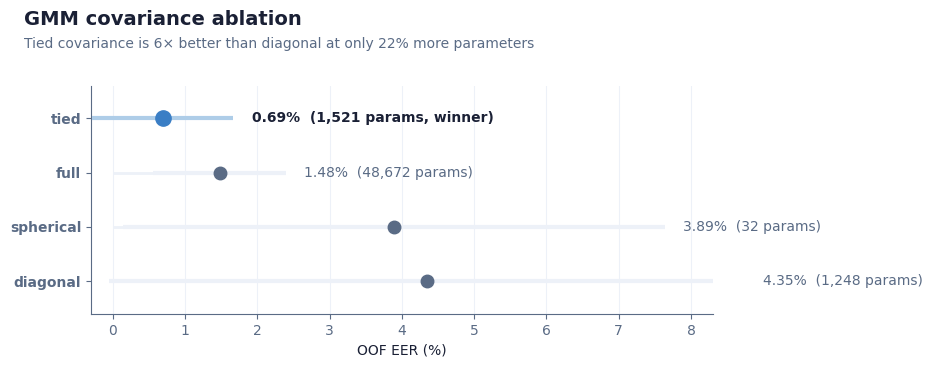

In [2]:
cov = [
    ("spherical",  3.89, 3.75,    32, False),
    ("diagonal",   4.35, 4.40,  1248, False),
    ("full",       1.48, 0.92, 48672, False),
    ("tied",       0.69, 0.98,  1521,  True),
]
labels = [c[0] for c in cov]
eer    = np.array([c[1] for c in cov])
err    = np.array([c[2] for c in cov])
params = np.array([c[3] for c in cov])
winner = np.array([c[4] for c in cov])

order = np.argsort(eer)[::-1]
labels = [labels[i] for i in order]
eer, err, params, winner = eer[order], err[order], params[order], winner[order]

fig, ax = plt.subplots(figsize=(7.4, 3.8))
fig.subplots_adjust(top=0.78, left=0.13, right=0.97, bottom=0.18)
for i, (lab, e, w, n, win) in enumerate(zip(labels, eer, err, params, winner)):
    color = P["audio"]    if win else P["sub"]
    light = P["audio_lt"] if win else P["grid"]
    ax.errorbar(e, i, xerr=w, fmt="o", ms=11 if win else 9,
                color=color, ecolor=light, elinewidth=3, capsize=0,
                mfc=color, mec=color, zorder=3)
    ax.hlines(i, 0, e, color=light, lw=2, zorder=2)
    ax.text(e + w + 0.25, i,
            f"{e:.2f}%  ({n:,} params{', winner' if win else ''})",
            va="center", color=P["ink"] if win else P["sub"],
            fontweight="bold" if win else "normal", fontsize=10)

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontweight="bold")
ax.set_xlabel("OOF EER (%)")
ax.set_xlim(-0.3, 8.3)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.grid(axis="x", color=P["grid"], lw=0.8); ax.set_axisbelow(True)
fig.text(0.04, 0.94, "GMM covariance ablation",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.88, "Tied covariance is 6× better than diagonal at only 22% more parameters",
         color=P["sub"], fontsize=10)
save(fig, "fig1_covariance_ablation")
plt.show()


## alt_a — Image robustness (E028 / E051, §4)

saved alt_a_image_robustness


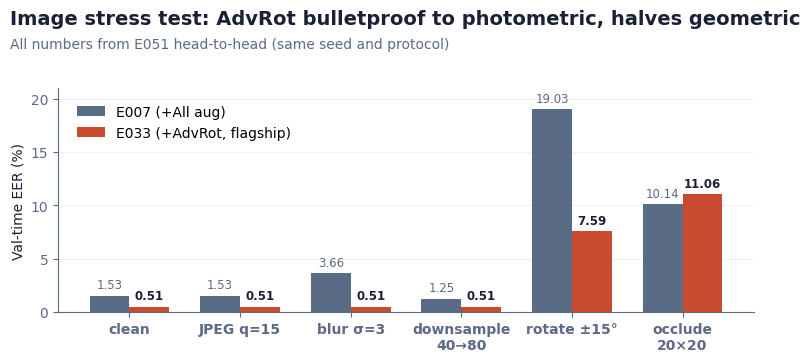

In [3]:
conds = ["clean", "JPEG q=15", "blur σ=3", "downsample\n40→80", "rotate ±15°", "occlude\n20×20"]
e007  = [1.53, 1.53, 3.66, 1.25, 19.03, 10.14]   # E051 head-to-head
e033  = [0.51, 0.51, 0.51, 0.51,  7.59, 11.06]   # E051 head-to-head

x = np.arange(len(conds)); w = 0.36
fig, ax = plt.subplots(figsize=(8.0, 4.0))
fig.subplots_adjust(top=0.78, left=0.10, right=0.97, bottom=0.22)
b1 = ax.bar(x - w/2, e007, w, color=P["sub"],   label="E007 (+All aug)",          zorder=3)
b2 = ax.bar(x + w/2, e033, w, color=P["image"], label="E033 (+AdvRot, flagship)", zorder=3)
for bars, vals in ((b1, e007), (b2, e033)):
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8.5,
                color=P["ink"] if bars is b2 else P["sub"],
                fontweight="bold" if bars is b2 else "normal")
ax.set_xticks(x); ax.set_xticklabels(conds, fontweight="bold")
ax.set_ylabel("Val-time EER (%)")
ax.set_ylim(0, 21)
ax.grid(axis="y", color=P["grid"], lw=0.8); ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(0.01, 0.98))
fig.text(0.04, 0.94, "Image stress test: AdvRot bulletproof to photometric, halves geometric",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.88, "All numbers from E051 head-to-head (same seed and protocol)",
         color=P["sub"], fontsize=10)
save(fig, "alt_a_image_robustness")
plt.show()


## Fig 6 — DET curves with fusion star (E039, §5)

saved fig6_det_curve


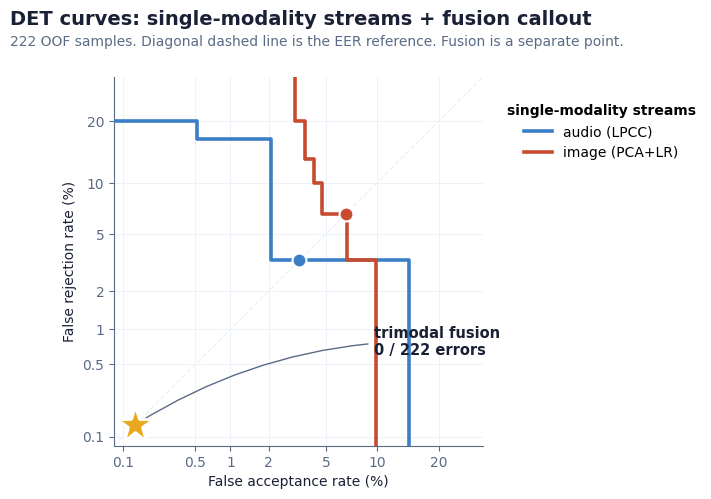

In [4]:
from sklearn.metrics import roc_curve

def det_points(score, y, eps=5e-4):
    fpr, tpr, _ = roc_curve(y, score)
    fnr = 1 - tpr
    fpr = np.clip(fpr, eps, 1 - eps)
    fnr = np.clip(fnr, eps, 1 - eps)
    return norm.ppf(fpr), norm.ppf(fnr)

def eer_point(score, y):
    fpr_grid = np.linspace(1e-4, 0.5, 50000)
    fpr, tpr, _ = roc_curve(y, score)
    fnr = 1 - tpr
    fnr_at = np.interp(fpr_grid, fpr, fnr)
    idx = np.argmin(np.abs(fpr_grid - fnr_at))
    return float(fpr_grid[idx]), float(fnr_at[idx])

oof = pickle.load(open(ROOT / "cache" / "oof_scores.pkl", "rb"))
y = oof["y"]

# Only the two single-modality streams have meaningful DET curves.
# Fusion makes 0/222 errors so its DET collapses to one point (the gold star).
streams = [
    ("audio (LPCC)",   oof["lpcc"],   P["audio"]),
    ("image (PCA+LR)", oof["image"], P["image"]),
]

fig, ax = plt.subplots(figsize=(7.4, 5.2))
fig.subplots_adjust(top=0.84, left=0.12, right=0.74, bottom=0.13)

xlim = (norm.ppf(0.0008), norm.ppf(0.30))
ylim = (norm.ppf(0.0008), norm.ppf(0.30))
ticks_pct = [0.1, 0.5, 1, 2, 5, 10, 20]
ticks_p   = [norm.ppf(t/100) for t in ticks_pct]
labels_t  = [f"{t:g}" for t in ticks_pct]

# diagonal EER reference line
ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], "--", color=P["grid"], lw=1, zorder=1)

for lab, s, c in streams:
    xv, yv = det_points(s, y)
    ax.plot(xv, yv, "-", lw=2.6, color=c, label=lab, zorder=3)
    fpr_e, fnr_e = eer_point(s, y)
    ax.plot(np.clip(norm.ppf(fpr_e), xlim[0]+0.05, xlim[1]-0.05),
            np.clip(norm.ppf(fnr_e), ylim[0]+0.05, ylim[1]-0.05),
            "o", ms=10, color=c, mec="white", mew=1.5, zorder=4)

# Trimodal fusion as an annotation only (no curve, no legend entry).
sx = xlim[0] + 0.15
sy = ylim[0] + 0.15
ax.plot(sx, sy, marker="*", ms=28, color=P["amber"],
        mec="white", mew=2.0, zorder=6)
ax.annotate("trimodal fusion\n0 / 222 errors",
            xy=(sx, sy),
            xytext=(sx + 1.7, sy + 0.5),
            color=P["ink"], fontsize=10.5, fontweight="bold",
            ha="left",
            arrowprops=dict(arrowstyle="-", color=P["sub"], lw=1.0,
                            connectionstyle="arc3,rad=0.15"))

ax.set_xticks(ticks_p); ax.set_xticklabels(labels_t)
ax.set_yticks(ticks_p); ax.set_yticklabels(labels_t)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel("False acceptance rate (%)")
ax.set_ylabel("False rejection rate (%)")
ax.grid(color=P["grid"], lw=0.7, zorder=0); ax.set_axisbelow(True)
ax.set_aspect("equal")

# legend OUTSIDE the plot
ax.legend(loc="center left", bbox_to_anchor=(1.03, 0.85),
          frameon=False, fontsize=10, title="single-modality streams",
          title_fontproperties={"weight": "bold", "size": 10})

fig.text(0.04, 0.94, "DET curves: single-modality streams + fusion callout",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.90, "222 OOF samples. Diagonal dashed line is the EER reference. Fusion is a separate point.",
         color=P["sub"], fontsize=10)

save(fig, "fig6_det_curve")
plt.show()


## alt_c — Audio × image complementarity (§5)

saved alt_c_complementarity


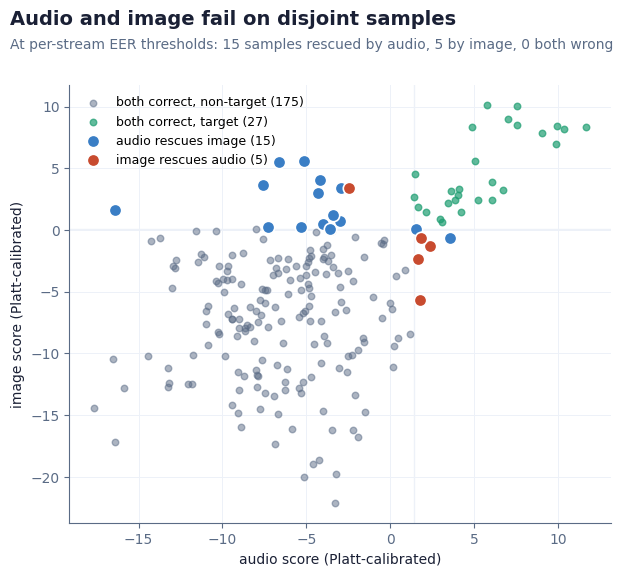

In [5]:
from sklearn.linear_model import LogisticRegression

oof = pickle.load(open(ROOT / "cache" / "oof_scores.pkl", "rb"))
y = oof["y"]

def platt(score):
    cal = LogisticRegression(C=1e6, max_iter=1000, class_weight="balanced")
    cal.fit(score.reshape(-1, 1), y)
    return cal.decision_function(score.reshape(-1, 1))

def eer_threshold(score):
    fpr, tpr, thr = roc_curve(y, score)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(thr[idx])

sa = platt(oof["lpcc"])
si = platt(oof["image"])
ta = eer_threshold(sa)
ti = eer_threshold(si)

da = sa >= ta
di = si >= ti
both_right       = (da == y) & (di == y)
audio_right_only = (da == y) & (di != y)
image_right_only = (da != y) & (di == y)
both_wrong       = (da != y) & (di != y)

fig, ax = plt.subplots(figsize=(6.6, 6.0))
fig.subplots_adjust(top=0.85, left=0.13, right=0.95, bottom=0.12)
ax.axhline(ti, color=P["grid"], lw=1, zorder=1)
ax.axvline(ta, color=P["grid"], lw=1, zorder=1)

ax.scatter(sa[both_right & (y == 0)], si[both_right & (y == 0)],
           s=22, color=P["sub"],   alpha=0.5,
           label=f"both correct, non-target ({((both_right) & (y==0)).sum()})", zorder=2)
ax.scatter(sa[both_right & (y == 1)], si[both_right & (y == 1)],
           s=22, color=P["fusion"], alpha=0.7,
           label=f"both correct, target ({((both_right) & (y==1)).sum()})", zorder=2)
ax.scatter(sa[audio_right_only], si[audio_right_only],
           s=80, color=P["audio"], edgecolor="white", lw=1.2,
           label=f"audio rescues image ({audio_right_only.sum()})", zorder=4)
ax.scatter(sa[image_right_only], si[image_right_only],
           s=80, color=P["image"], edgecolor="white", lw=1.2,
           label=f"image rescues audio ({image_right_only.sum()})", zorder=4)
if both_wrong.any():
    ax.scatter(sa[both_wrong], si[both_wrong],
               s=120, color=P["amber"], marker="X", edgecolor="white", lw=1.2,
               label=f"both wrong ({both_wrong.sum()})", zorder=5)

ax.set_xlabel("audio score (Platt-calibrated)")
ax.set_ylabel("image score (Platt-calibrated)")
ax.grid(color=P["grid"], lw=0.7, zorder=0); ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False, fontsize=9, bbox_to_anchor=(0.0, 1.0))

fig.text(0.04, 0.95, "Audio and image fail on disjoint samples",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.91,
         f"At per-stream EER thresholds: {audio_right_only.sum()} samples rescued by audio, "
         f"{image_right_only.sum()} by image, {both_wrong.sum()} both wrong",
         color=P["sub"], fontsize=10)
save(fig, "alt_c_complementarity")
plt.show()


## alt_b — Project-arc progression (§7)

saved alt_b_progression


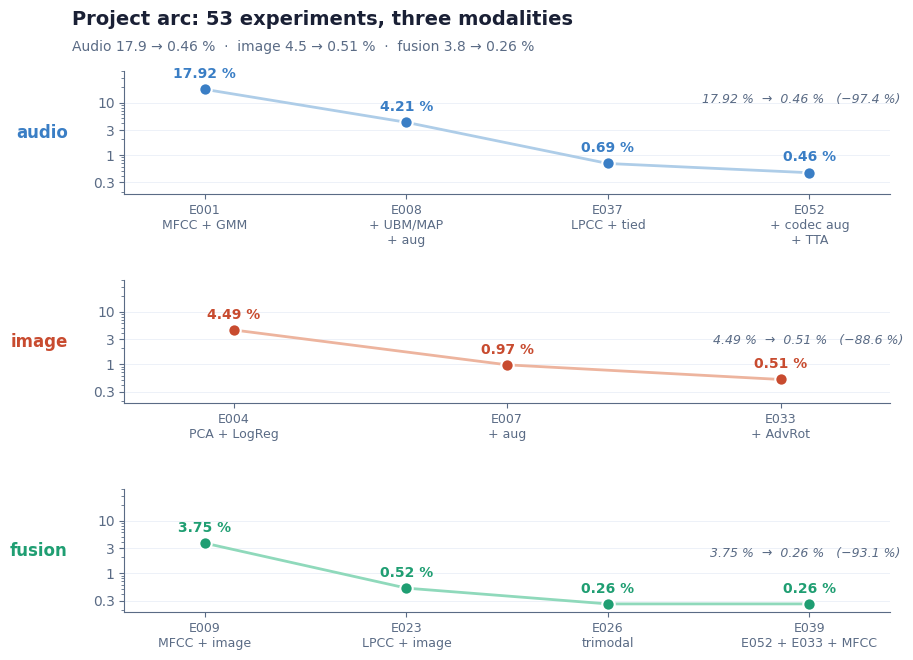

In [6]:
tracks = [
    ("audio",  P["audio"],  P["audio_lt"],
     ["E001\nMFCC + GMM", "E008\n+ UBM/MAP\n+ aug", "E037\nLPCC + tied", "E052\n+ codec aug\n+ TTA"],
     [17.92, 4.21, 0.69, 0.46]),
    ("image",  P["image"],  P["image_lt"],
     ["E004\nPCA + LogReg", "E007\n+ aug", "E033\n+ AdvRot"],
     [4.49, 0.97, 0.51]),
    ("fusion", P["fusion"], P["fusion_lt"],
     ["E009\nMFCC + image", "E023\nLPCC + image", "E026\ntrimodal", "E039\nE052 + E033 + MFCC"],
     [3.75, 0.52, 0.26, 0.26]),
]

fig, axes = plt.subplots(3, 1, figsize=(8.8, 6.6), gridspec_kw=dict(hspace=0.7))
fig.subplots_adjust(top=0.88, left=0.10, right=0.97, bottom=0.06)

for ax, (name, c, c_lt, xlabs, ys) in zip(axes, tracks):
    n = len(xlabs); xs = np.arange(n)
    ax.plot(xs, ys, "-", color=c_lt, lw=2, zorder=2)
    ax.scatter(xs, ys, s=80, color=c, edgecolor="white", lw=1.5, zorder=3)
    for xv, yv in zip(xs, ys):
        ax.text(xv, yv * 1.45, f"{yv:.2f} %",
                ha="center", va="bottom", fontsize=10,
                color=c, fontweight="bold")
    ax.set_yscale("log")
    ax.set_ylim(0.18, max(40, ys[0] * 2))
    ax.set_yticks([0.3, 1, 3, 10])
    ax.set_yticklabels(["0.3", "1", "3", "10"])
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabs, color=P["sub"], fontsize=9)
    ax.set_xlim(-0.4, n - 0.6)
    ax.grid(axis="y", color=P["grid"], lw=0.7); ax.set_axisbelow(True)
    ax.set_ylabel(name, color=c, fontsize=12, fontweight="bold",
                  rotation=0, ha="right", va="center", labelpad=18)
    drop = (1 - ys[-1] / ys[0]) * 100
    ax.text(n - 0.55, ys[0] * 0.85,
            f"{ys[0]:.2f} %  →  {ys[-1]:.2f} %   (−{drop:.1f} %)",
            ha="right", va="top", color=P["sub"], fontsize=9, style="italic")

fig.text(0.04, 0.95, "Project arc: 53 experiments, three modalities",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.91, "Audio 17.9 → 0.46 %  ·  image 4.5 → 0.51 %  ·  fusion 3.8 → 0.26 %",
         color=P["sub"], fontsize=10)
save(fig, "alt_b_progression")
plt.show()
